1. Загрузить данные

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Загрузка
df = pd.read_csv('segmentation_data.csv')

# Первые строки
print("Первые 5 строк:")
df.head()

Первые 5 строк:


,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


In [3]:
df.describe()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,5.774946e+02,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,1.000000e+08,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,1.000005e+08,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,1.000010e+08,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000015e+08,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000020e+08,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


In [4]:
df.isnull().sum()

,0
ID,0
Sex,0
Marital status,0
Age,0
Education,0
Income,0
Occupation,0
Settlement size,0


In [5]:
df = df.drop('ID', axis=1)

# Проверяем результат
print("Признаки для кластеризации:")
print(df.columns.tolist())
print(f"Размер: {df.shape}")

Признаки для кластеризации:
['Sex', 'Marital status', 'Age', 'Education', 'Income', 'Occupation', 'Settlement size']
Размер: (2000, 7)


2 Нормализовать данные

In [7]:
# Создаём копию для нормализации
df_scaled = df.copy()

# Нормализация (StandardScaler)
scaler = StandardScaler()
df_scaled[df.columns] = scaler.fit_transform(df)

# Проверяем результат
print("После нормализации:")
print(f"Mean:\n{df_scaled.mean().round(3)}")
print(f"Std:\n{df_scaled.std().round(3)}")

df_scaled.head()

После нормализации:
Mean:
Sex               -0.0
Marital status     0.0
Age                0.0
Education         -0.0
Income             0.0
Occupation         0.0
Settlement size    0.0
dtype: float64
Std:
Sex                1.0
Marital status     1.0
Age                1.0
Education          1.0
Income             1.0
Occupation         1.0
Settlement size    1.0
dtype: float64


,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,-0.917399,-0.993024,2.653614,1.604323,0.097524,0.296823,1.552326
1,1.090038,1.007025,-1.187132,-0.063372,0.782654,0.296823,1.552326
2,-0.917399,-0.993024,1.117316,-0.063372,-0.833202,-1.269525,-0.909730
3,-0.917399,-0.993024,0.775916,-0.063372,1.328386,0.296823,0.321298
4,-0.917399,-0.993024,1.458716,-0.063372,0.736932,0.296823,0.321298


# 3. Создать копию данных, преобразовав их с помощью PCA

In [8]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Создаём DataFrame с результатами PCA
df_pca_result = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])

print("Доля объяснённой дисперсии:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Суммарно: {pca.explained_variance_ratio_.sum():.3f}")

Доля объяснённой дисперсии:
PC1: 0.357
PC2: 0.263
Суммарно: 0.619


4 Отобразить на плоскости данные из п.3

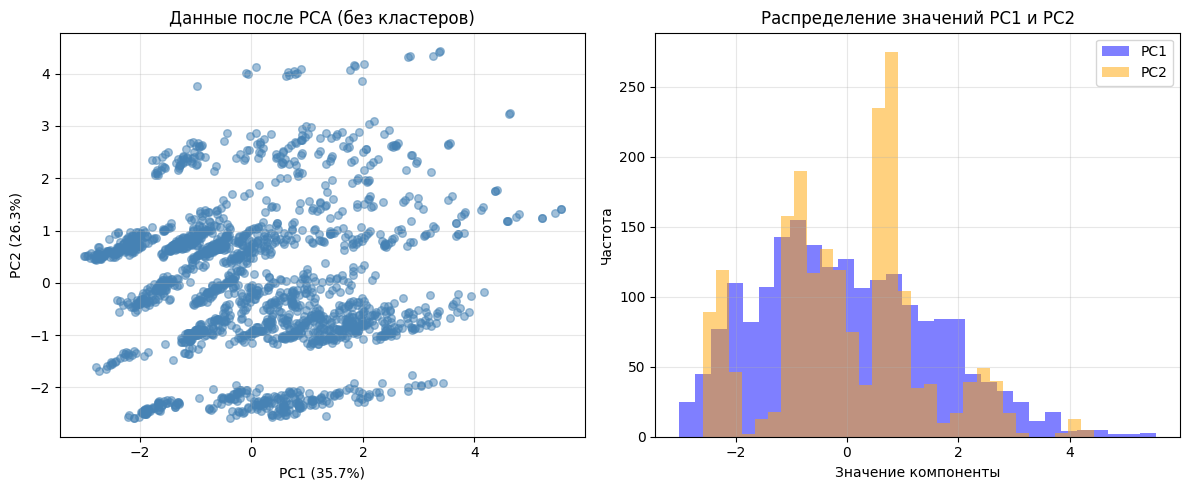

In [9]:
plt.figure(figsize=(12, 5))

# График 1: Точки без кластеров
plt.subplot(1, 2, 1)
plt.scatter(df_pca_result['PC1'], df_pca_result['PC2'],
            alpha=0.5, s=30, c='steelblue')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Данные после PCA (без кластеров)')
plt.grid(alpha=0.3)

# График 2: Распределение по компонентам
plt.subplot(1, 2, 2)
plt.hist(df_pca_result['PC1'], bins=30, alpha=0.5, label='PC1', color='blue')
plt.hist(df_pca_result['PC2'], bins=30, alpha=0.5, label='PC2', color='orange')
plt.xlabel('Значение компоненты')
plt.ylabel('Частота')
plt.title('Распределение значений PC1 и PC2')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

5 Провести кластеризацию методом KMeans, подобрав количество кластеров

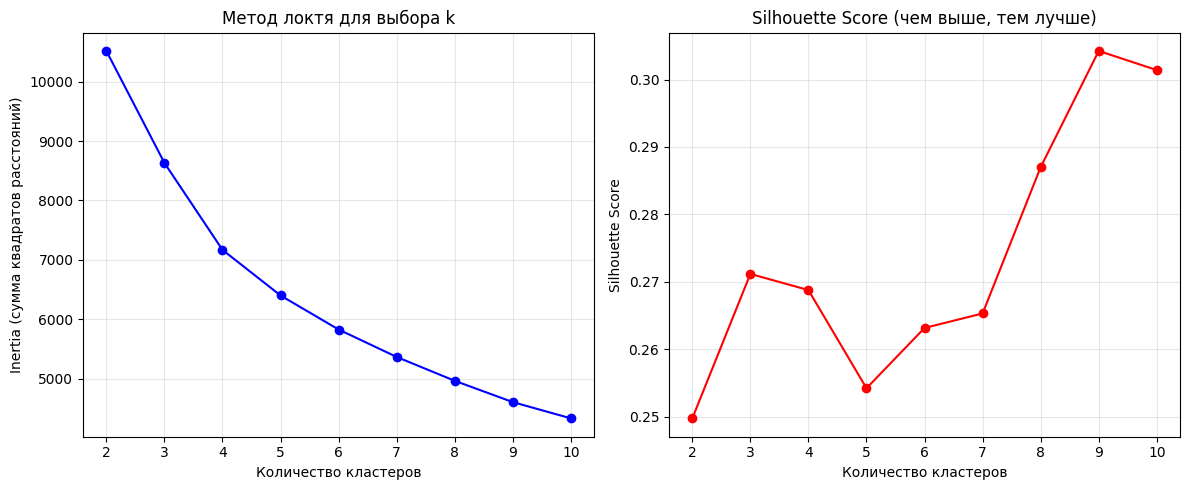

KMeans результаты:
k=2: Inertia=10514, Silhouette=0.250
k=3: Inertia=8632, Silhouette=0.271
k=4: Inertia=7170, Silhouette=0.269
k=5: Inertia=6403, Silhouette=0.254
k=6: Inertia=5831, Silhouette=0.263
k=7: Inertia=5370, Silhouette=0.265
k=8: Inertia=4969, Silhouette=0.287
k=9: Inertia=4611, Silhouette=0.304
k=10: Inertia=4337, Silhouette=0.301


In [10]:
from sklearn.cluster import KMeans

# Подбираем количество кластеров от 2 до 10
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)  # Кластеризуем на исходных 7 признаках
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Визуализация
plt.figure(figsize=(12, 5))

# График 1: Inertia (метод локтя)
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia (сумма квадратов расстояний)')
plt.title('Метод локтя для выбора k')
plt.grid(alpha=0.3)

# График 2: Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score (чем выше, тем лучше)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод значений
print("KMeans результаты:")
for k in K_range:
    print(f"k={k}: Inertia={inertias[k-2]:.0f}, Silhouette={silhouette_scores[k-2]:.3f}")

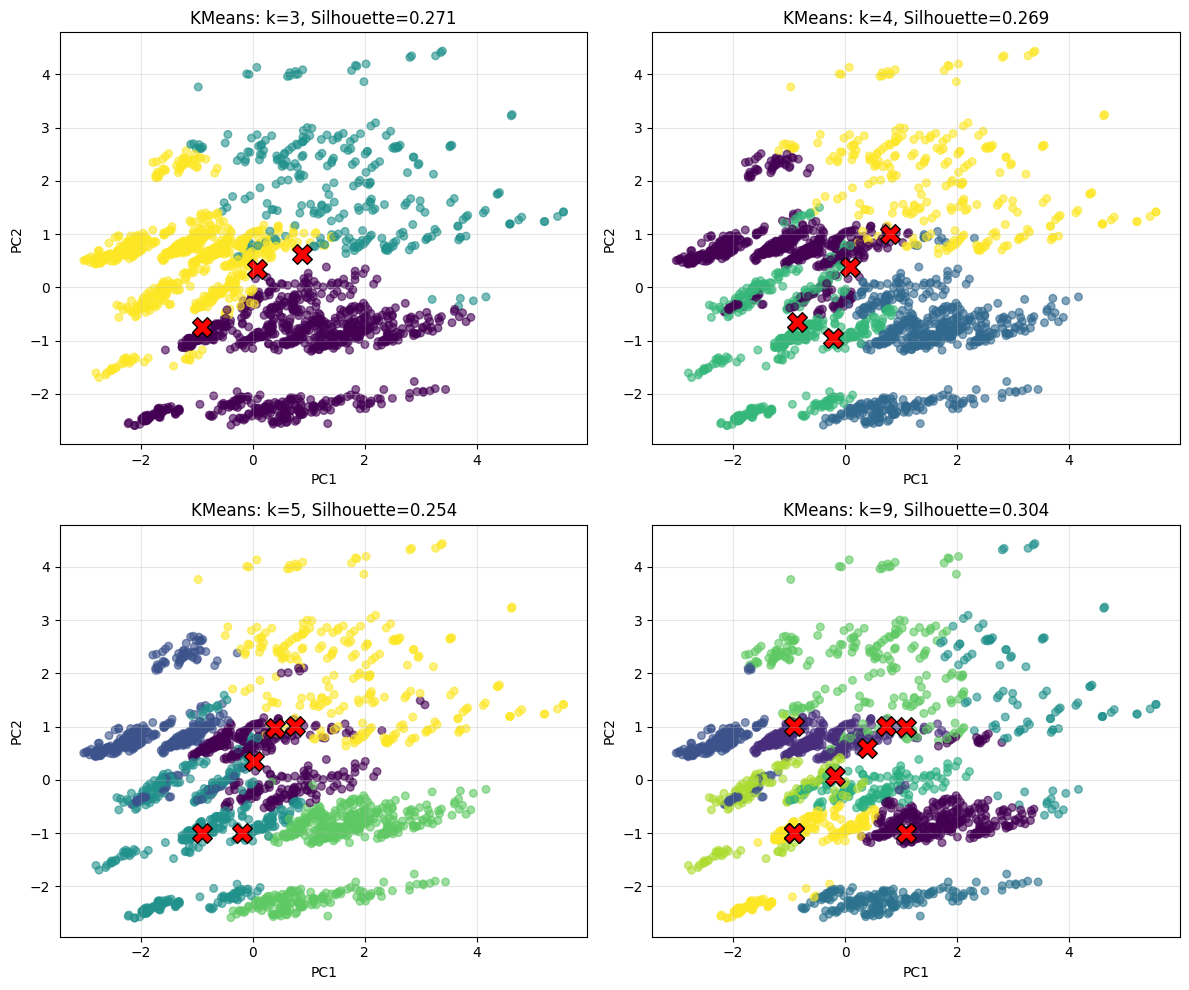

In [11]:
# Визуализация разных k на плоскости PCA
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ks_to_try = [3, 4, 5, 9]

for ax, k in zip(axes.ravel(), ks_to_try):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)

    # Цвета для кластеров
    scatter = ax.scatter(df_pca_result['PC1'], df_pca_result['PC2'],
                         c=labels, cmap='viridis', alpha=0.6, s=30)
    ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
               marker='X', c='red', s=200, edgecolors='black')
    ax.set_title(f'KMeans: k={k}, Silhouette={silhouette_score(df_scaled, labels):.3f}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Обучаем KMeans с k=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_final.fit_predict(df_scaled)

# Смотрим, сколько клиентов в каждом кластере
print("Распределение по кластерам KMeans:")
print(df['KMeans_Cluster'].value_counts().sort_index())

# Центры кластеров (в нормализованном масштабе)
centroids = kmeans_final.cluster_centers_
print("\nЦентры кластеров (нормализованные):")
for i, center in enumerate(centroids):
    print(f"Кластер {i}: {center.round(3)}")

Распределение по кластерам KMeans:
KMeans_Cluster
0    859
1    282
2    859
Name: count, dtype: int64

Центры кластеров (нормализованные):
Кластер 0: [-0.906 -0.735 -0.044 -0.558  0.132  0.209  0.35 ]
Кластер 1: [0.072 0.34  1.636 1.734 0.993 0.508 0.457]
Кластер 2: [ 0.882  0.623 -0.493 -0.011 -0.457 -0.376 -0.5  ]


6 Провести агломеративную кластеризацию, подобрав количество кластеров с помощью дендрограммы

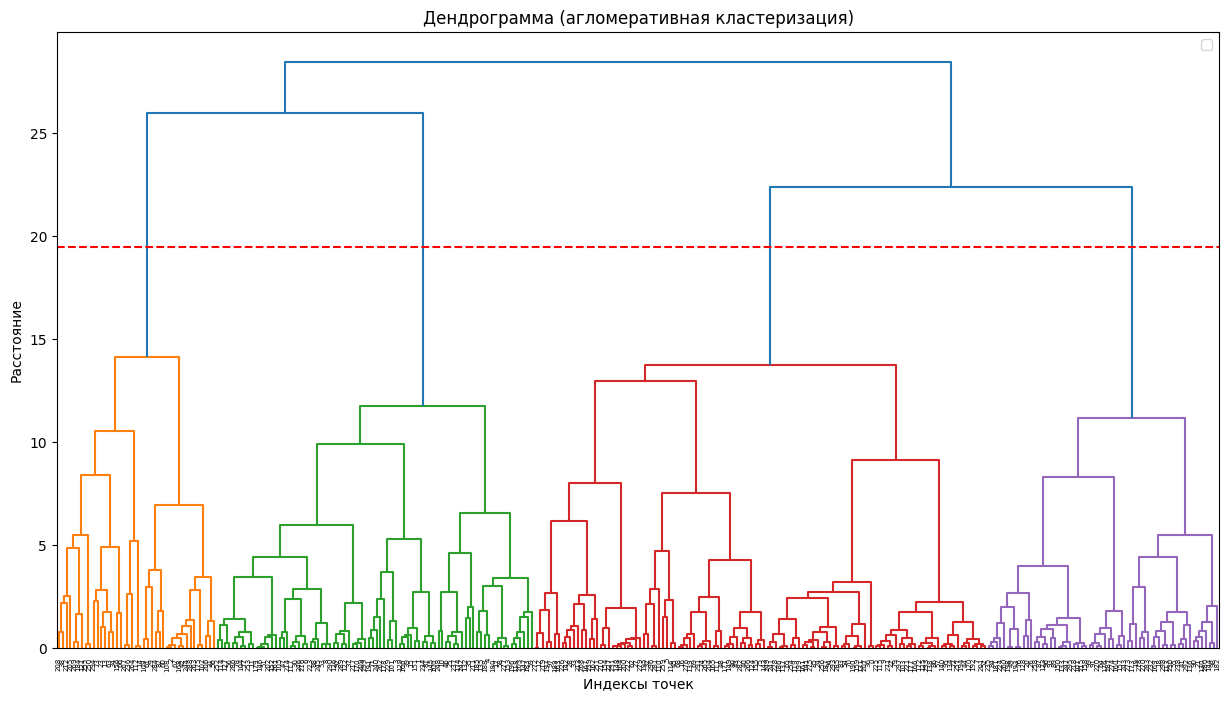

In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Для дендрограммы используем небольшой подвыборки (300 точек),
# иначе график будет перегружен
sample_size = 300
np.random.seed(42)
sample_idx = np.random.choice(df_scaled.index, sample_size, replace=False)
df_sample = df_scaled.iloc[sample_idx]

# Вычисляем матрицу связей
linked = linkage(df_sample, method='ward')

# Рисуем дендрограмму
plt.figure(figsize=(15, 8))
dendrogram(linked, orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.axhline(y=19.5, color='r', linestyle='--')
plt.title('Дендрограмма (агломеративная кластеризация)')
plt.xlabel('Индексы точек')
plt.ylabel('Расстояние')
plt.legend()
plt.show()

In [20]:
from sklearn.cluster import AgglomerativeClustering

optimal_k = 4

# Проводим агломеративную кластеризацию
agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df['Agglo_Cluster'] = agglo.fit_predict(df_scaled)

# Проверяем результат
print("Распределение по кластерам (агломеративная):")
print(df['Agglo_Cluster'].value_counts().sort_index())

Распределение по кластерам (агломеративная):
Agglo_Cluster
0    649
1    579
2    241
3    531
Name: count, dtype: int64


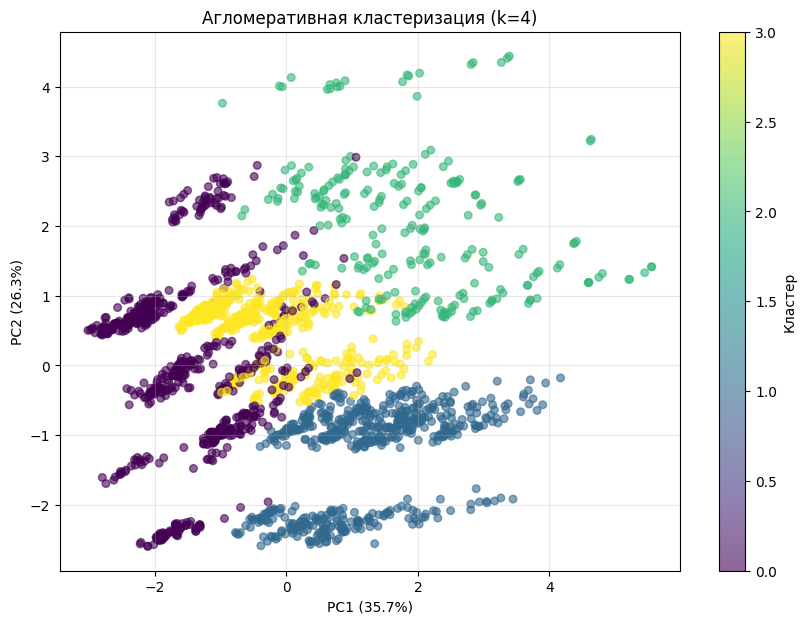

In [21]:
# Наносим кластеры на плоскость PCA
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca_result['PC1'], df_pca_result['PC2'],
                      c=df['Agglo_Cluster'], cmap='viridis', alpha=0.6, s=30)
plt.colorbar(scatter, label='Кластер')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title(f'Агломеративная кластеризация (k={optimal_k})')
plt.grid(alpha=0.3)
plt.show()

7 Выбрать наилучший метод

=== СРАВНЕНИЕ МЕТОДОВ ===
KMeans (k=3): Silhouette = 0.2712
Агломеративная (k=4): Silhouette = 0.2508



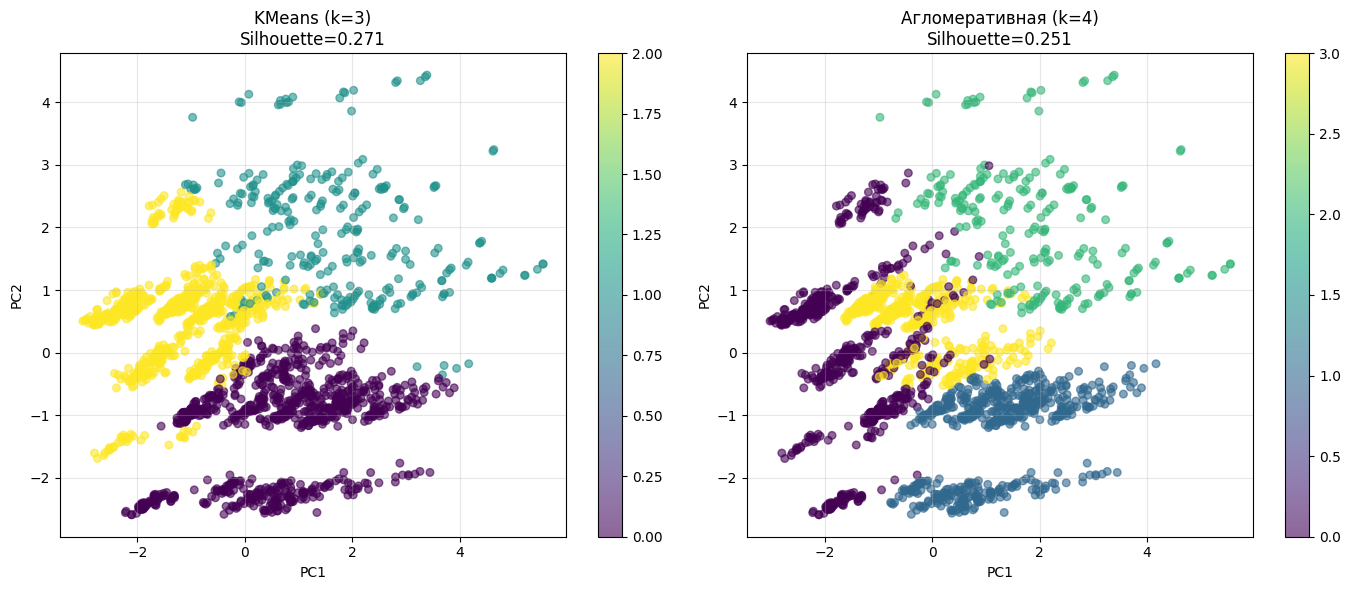

In [23]:
from sklearn.metrics import silhouette_score

# Оценка качества (для информации, но прямо не сравниваем)
sil_kmeans = silhouette_score(df_scaled, df['KMeans_Cluster'])
sil_agglo = silhouette_score(df_scaled, df['Agglo_Cluster'])

print(f"KMeans (k=3): Silhouette = {sil_kmeans:.4f}")
print(f"Агломеративная (k=4): Silhouette = {sil_agglo:.4f}")
print()

# Визуальное сравнение на плоскости PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KMeans (k=3)
scatter1 = axes[0].scatter(df_pca_result['PC1'], df_pca_result['PC2'],
                           c=df['KMeans_Cluster'], cmap='viridis', alpha=0.6, s=30)
axes[0].set_title(f'KMeans (k=3)\nSilhouette={sil_kmeans:.3f}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(alpha=0.3)
plt.colorbar(scatter1, ax=axes[0])

# Агломеративная (k=4)
scatter2 = axes[1].scatter(df_pca_result['PC1'], df_pca_result['PC2'],
                           c=df['Agglo_Cluster'], cmap='viridis', alpha=0.6, s=30)
axes[1].set_title(f'Агломеративная (k=4)\nSilhouette={sil_agglo:.3f}')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(alpha=0.3)
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

8 Проанализировать состав кластеров, используя визуализацию. Сделать выводы о том какие клиенты в каком кластере присутствуют. Для категориальных признаков для визуализации лучше использовать гистограммы, а для числовых - точечные графики

In [25]:
cluster_sizes = df['Agglo_Cluster'].value_counts().sort_index()
print(cluster_sizes.rename('Количество клиентов'))

print((cluster_sizes / len(df) * 100).round(1).rename('%'))

Agglo_Cluster
0    649
1    579
2    241
3    531
Name: Количество клиентов, dtype: int64
Agglo_Cluster
0    32.4
1    29.0
2    12.0
3    26.6
Name: %, dtype: float64


In [26]:
# Средние значения по кластерам
cluster_profiles = df.groupby('Agglo_Cluster').mean()
print(cluster_profiles.round(2))

                Sex  Marital status    Age  Education     Income  Occupation  \
Agglo_Cluster                                                                  
0              0.64            0.45  34.58       0.99   90807.33        0.10   
1              0.00            0.00  36.81       0.67  137369.34        1.18   
2              0.50            0.72  54.59       2.12  163924.68        1.26   
3              0.71            1.00  28.06       1.00  120399.59        1.08   

               Settlement size  KMeans_Cluster  
Agglo_Cluster                                   
0                         0.02            1.41  
1                         1.25            0.01  
2                         1.22            1.01  
3                         0.84            1.57  


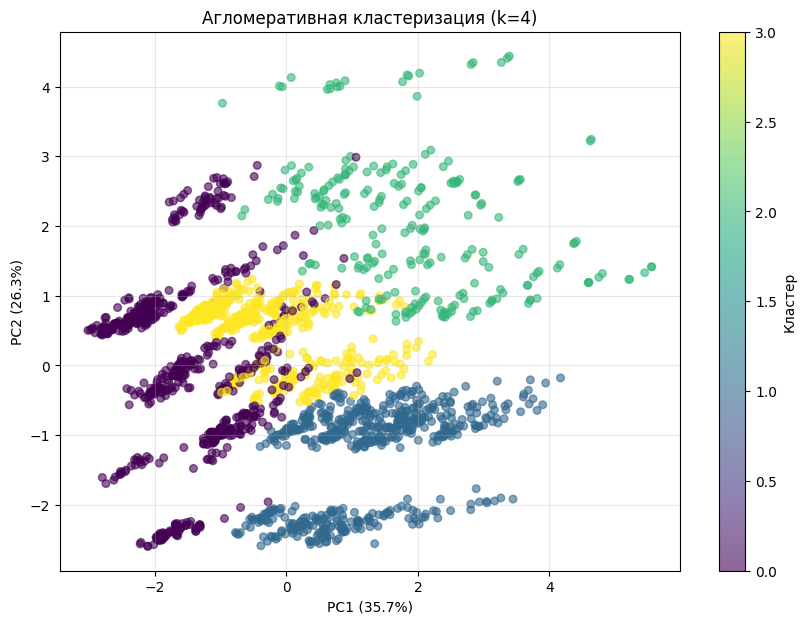

In [27]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_pca_result['PC1'], df_pca_result['PC2'],
                      c=df['Agglo_Cluster'], cmap='viridis', alpha=0.6, s=30)
plt.colorbar(scatter, label='Кластер')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Агломеративная кластеризация (k=4)')
plt.grid(alpha=0.3)
plt.show()

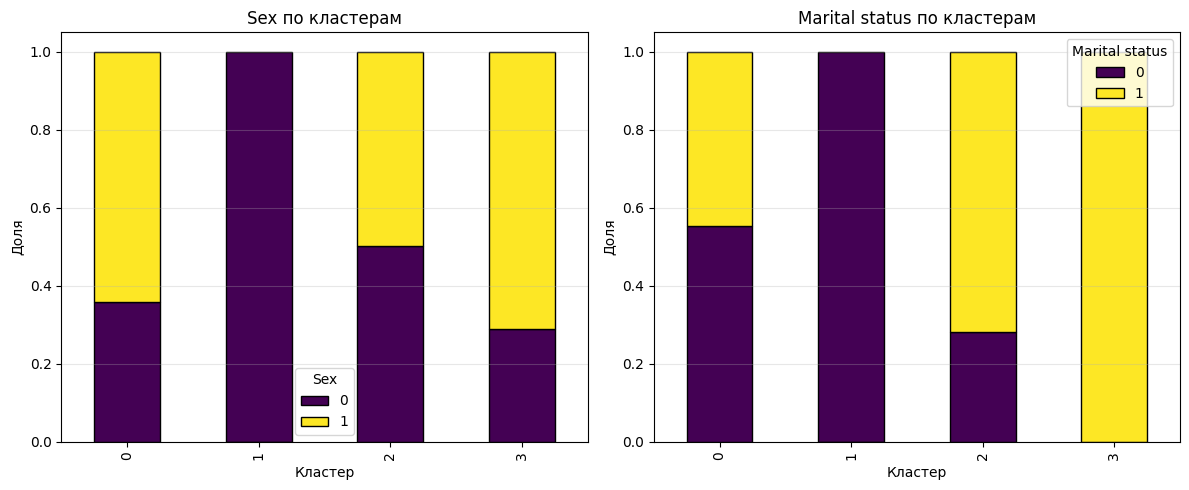

In [30]:
# Категориальные признаки (бинарные)
categorical_features = ['Sex', 'Marital status']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, feature in enumerate(categorical_features):
    # Группируем по кластеру и признаку
    plot_data = pd.crosstab(df['Agglo_Cluster'], df[feature], normalize='index')

    plot_data.plot(kind='bar', ax=axes[i], stacked=True, colormap='viridis', edgecolor='black')
    axes[i].set_title(f'{feature} по кластерам')
    axes[i].set_xlabel('Кластер')
    axes[i].set_ylabel('Доля')
    axes[i].legend(title=feature, labels=['0', '1'])
    axes[i].set_xticks(range(4))
    axes[i].set_xticklabels(range(4))
    axes[i].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

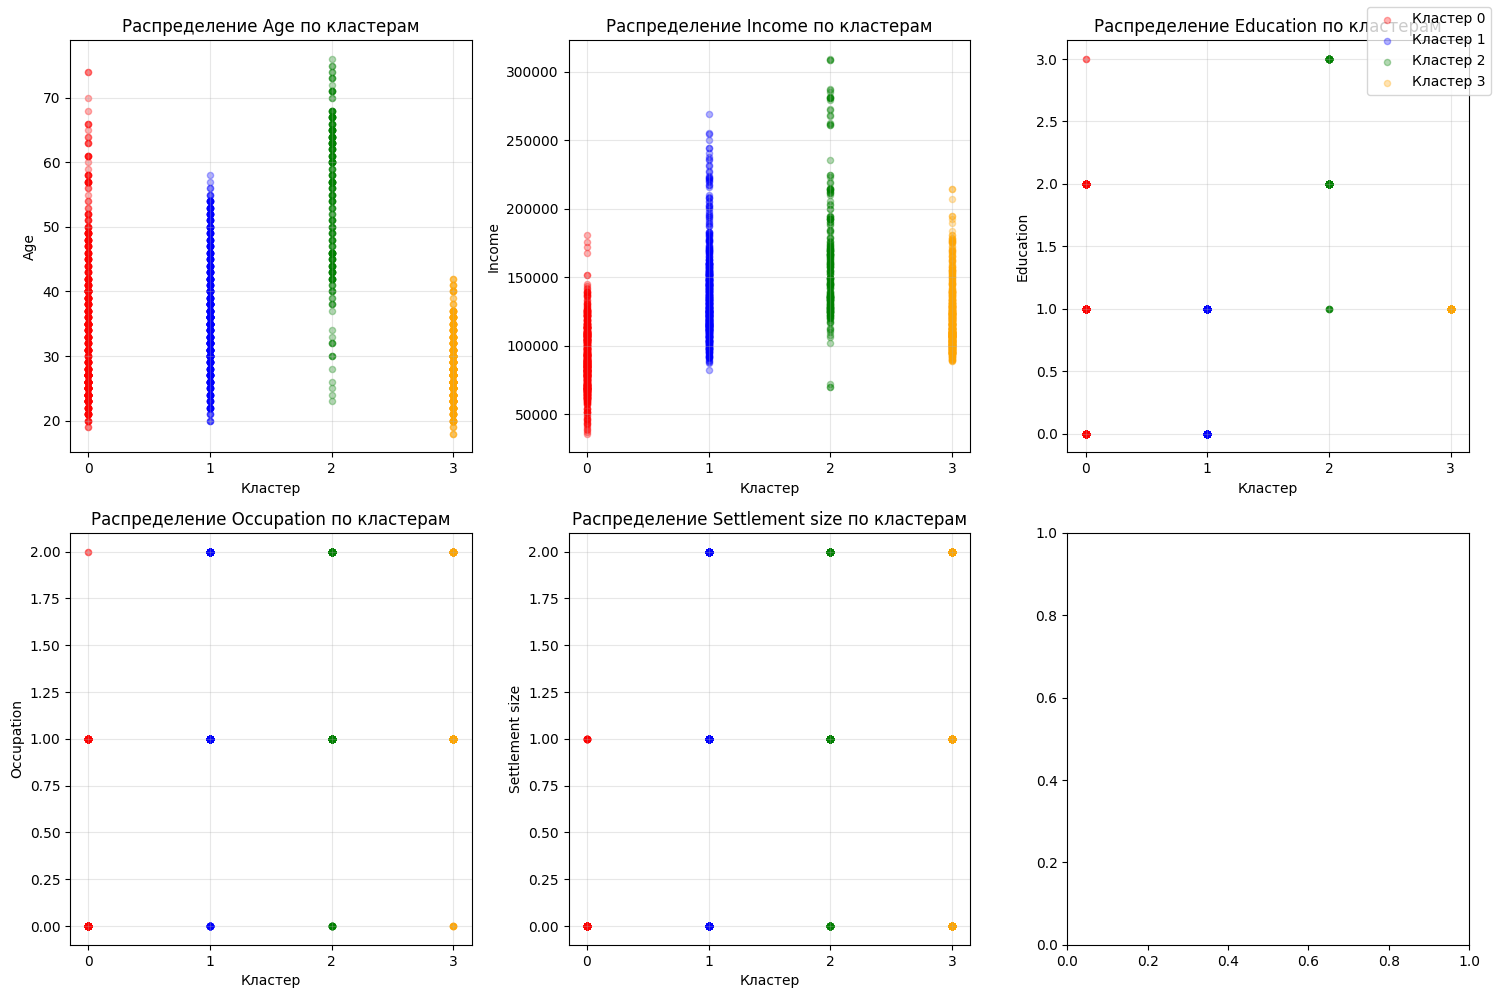

In [31]:
# Числовые признаки
numeric_features = ['Age', 'Income', 'Education', 'Occupation', 'Settlement size']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

colors = ['red', 'blue', 'green', 'orange']

for i, feature in enumerate(numeric_features):
    for cluster in range(4):
        cluster_data = df[df['Agglo_Cluster'] == cluster]
        axes[i].scatter([cluster] * len(cluster_data), cluster_data[feature],
                        alpha=0.3, s=20, color=colors[cluster], label=f'Кластер {cluster}')

    axes[i].set_xlabel('Кластер')
    axes[i].set_ylabel(feature)
    axes[i].set_title(f'Распределение {feature} по кластерам')
    axes[i].set_xticks(range(4))
    axes[i].grid(alpha=0.3)

# Убираем дублирующиеся легенды
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

КЛАСТЕР 0 — Сельские жители со средним доходом (32.5% клиентов)
Признак	Значение	Вывод
Возраст	34.6 лет	Молодые взрослые
Доход	90 800	Самый низкий доход
Образование	1.0	Среднее
Поселение	0.02	Почти все живут в сёлах
Женщины	36%	Преобладают мужчины
В браке	45%	~пополам
Портрет: Молодые мужчины и женщины со средним образованием, живущие в сельской местности. Доход ниже среднего.

КЛАСТЕР 1 — Одинокие работающие женщины (29.0% клиентов)
Признак	Значение	Вывод
Возраст	36.8 лет	Взрослые
Доход	137 400	Высокий доход
Образование	0.67	Ниже среднего
Поселение	1.25	Пригород
Женщины	100%	Только женщины
В браке	0%	Никто не в браке
Портрет: Одинокие женщины, работающие, с высоким доходом, живут в пригороде. Образование чуть ниже среднего.

КЛАСТЕР 2 — Пожилые обеспеченные семьи (12.1% клиентов)
Признак	Значение	Вывод
Возраст	54.6 лет	Самые старшие
Доход	163 900	Самый высокий доход
Образование	2.12	Высшее образование
Поселение	1.22	Пригород
Женщины	50%	Поровну
В браке	72%	Большинство в браке
Портрет: Пожилые супружеские пары с высшим образованием и самым высоким доходом. Живут в пригороде.

КЛАСТЕР 3 — Молодые семьи (26.6% клиентов)
Признак	Значение	Вывод
Возраст	28.1 лет	Самые молодые
Доход	120 400	Выше среднего
Образование	1.0	Среднее
Поселение	0.84	Пригород/село
Женщины	29%	Преобладают мужчины
В браке	100%	Все в браке
Портрет: Молодые семьи (преимущественно мужчины), среднее образование, доход выше среднего, живут в пригороде или селе.